In [2]:
# Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = True

ranked = pd.read_csv(
    "RankedTEPSet_TNT ULTRASPEC_r-band_for_Half_Well_Y-SkyNoise_N-Defocus.csv"
)

events = pd.read_csv(
    "Full_Event_List_for_TNT ULTRASPEC_r-band_for_Half_Well_Rank-modes_Y-SkyNoise_N-Defocus_97.0%_cut_from_Oct-01-2025_to_Jan-01-2026.csv"
)

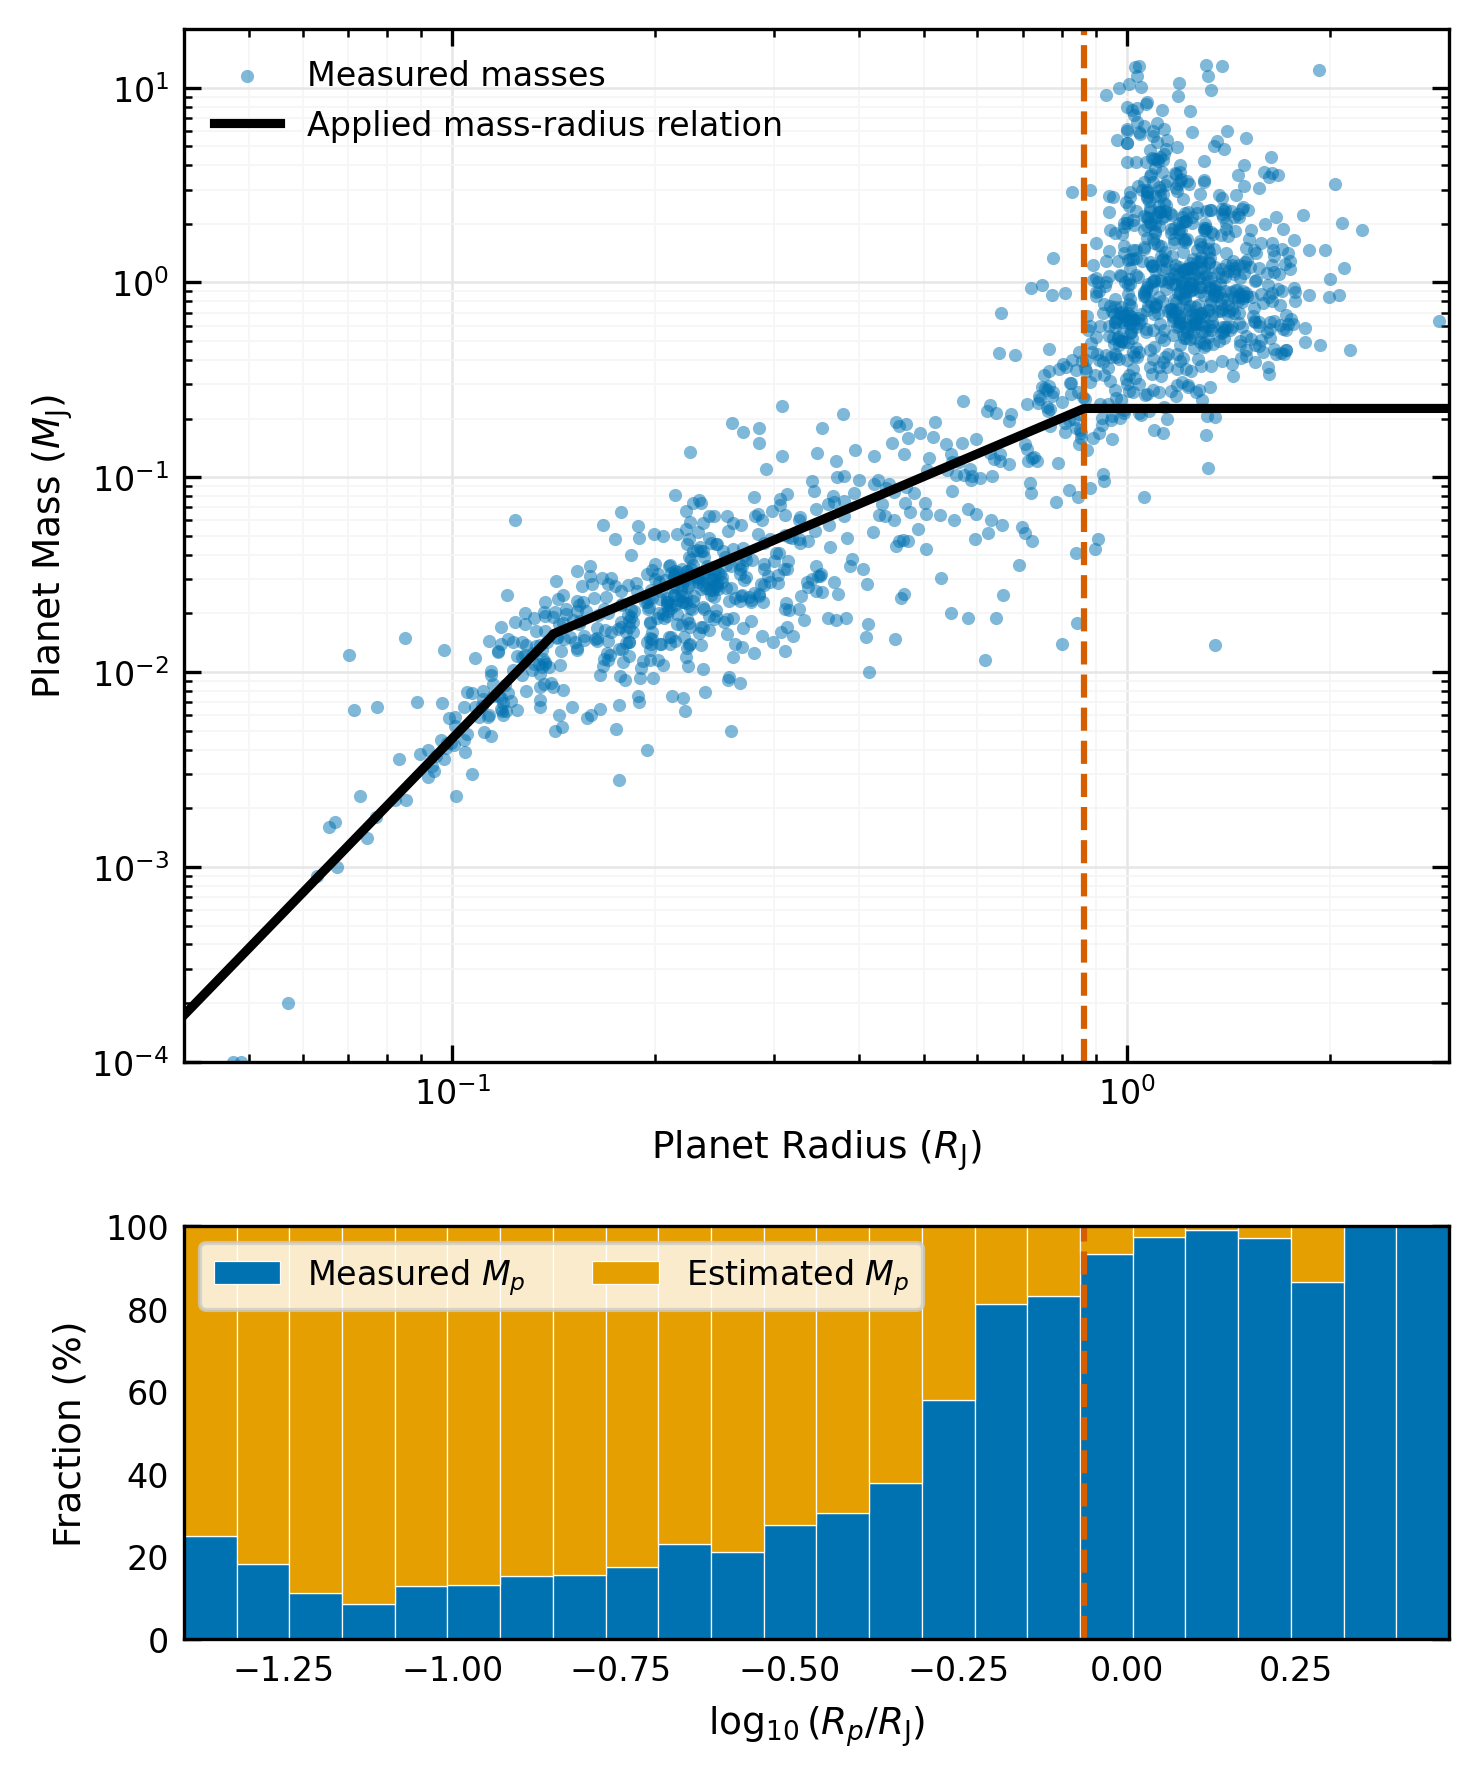

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
import astropy.units as u

# -----------------------------------------------------------------------------
# MNRAS-style plotting parameters
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 300,
})

# Okabe-Ito colourblind-safe palette
MR_COLOR = "#0072B2"         # Blue
VALID_COLOR = "#0072B2"
INVALID_COLOR = "#E69F00"    # Orange
BOUNDARY_COLOR = "#D55E00"   # Vermillion
CURVE_COLOR = "black"


# -----------------------------------------------------------------------------
# Mass-Radius relation
# -----------------------------------------------------------------------------
def Mp_Calc(row):
    Rp_Jup = row["Rp"]
    Rp_Ear = (Rp_Jup * u.R_jup).to(u.R_earth).value

    rocky_Rp_boundary = 1.01 * 4.95**0.28
    degenerate_Rp_boundary = 1.10 * 500**0.35

    if Rp_Ear < rocky_Rp_boundary:
        k, beta = 1.01, 0.28
        Mp_Calc_Ear = (Rp_Ear / k) ** (1 / beta)

    elif Rp_Ear < degenerate_Rp_boundary:
        k, beta = 0.53, 0.68
        Mp_Calc_Ear = (Rp_Ear / k) ** (1 / beta)

    else:
        k, beta = 0.53, 0.68
        Mp_Calc_Ear = (degenerate_Rp_boundary / k) ** (1 / beta)

    return (Mp_Calc_Ear * u.M_earth).to(u.M_jup).value


valid = ranked["Mp"].notna()

fig, ax = plt.subplots(
    2,
    1,
    figsize=(5, 6),
    gridspec_kw={"height_ratios": [3, 1.2]},
)

# =============================================================================
# Top panel
# =============================================================================
ax0 = ax[0]

ax0.scatter(
    ranked.loc[valid, "Rp"],
    ranked.loc[valid, "Mp"],
    s=10,
    color=MR_COLOR,
    alpha=0.5,
    linewidth=0,
    rasterized=True,
    label="Measured masses",
)

Rp_line = np.logspace(np.log10(4e-2), np.log10(3), 600)

curve = pd.DataFrame({"Rp": Rp_line})
curve["Mp"] = curve.apply(Mp_Calc, axis=1)

ax0.plot(
    curve["Rp"],
    curve["Mp"],
    color=CURVE_COLOR,
    lw=2.2,
    zorder=5,
    label="Applied mass-radius relation",
)

degenerate_Rp_boundary = (
    (1.10 * 500**0.35 * u.R_earth)
    .to(u.R_jup)
    .value
)

ax0.axvline(
    degenerate_Rp_boundary,
    color=BOUNDARY_COLOR,
    ls="--",
    lw=1.5,
)

ax0.set_xscale("log")
ax0.set_yscale("log")

ax0.set_xlim(4e-2, 3)
ax0.set_ylim(1e-4, 2e1)

ax0.set_xlabel(r"Planet Radius ($R_\mathrm{J}$)")
ax0.set_ylabel(r"Planet Mass ($M_\mathrm{J}$)")

ax0.legend(
    frameon=False,
    loc="upper left",
    ncol=1,
)

ax0.xaxis.set_major_locator(LogLocator(base=10))
ax0.yaxis.set_major_locator(LogLocator(base=10))
ax0.minorticks_on()

# =============================================================================
# Bottom panel
# =============================================================================
ax1 = ax[1]

Rp_log = np.log10(ranked["Rp"])

bins = np.linspace(np.log10(4e-2), np.log10(3), 25)

counts_valid, edges = np.histogram(Rp_log[valid], bins=bins)
counts_invalid, _ = np.histogram(Rp_log[~valid], bins=bins)

total = counts_valid + counts_invalid

valid_pct = np.divide(
    counts_valid,
    total,
    out=np.zeros_like(counts_valid, dtype=float),
    where=total > 0,
) * 100

invalid_pct = 100 - valid_pct

centers = (edges[:-1] + edges[1:]) / 2
width = np.diff(edges)

ax1.bar(
    centers,
    valid_pct,
    width=width,
    color=VALID_COLOR,
    edgecolor="white",
    linewidth=0.3,
    label=r"Measured $M_p$",
)

ax1.bar(
    centers,
    invalid_pct,
    width=width,
    bottom=valid_pct,
    color=INVALID_COLOR,
    edgecolor="white",
    linewidth=0.3,
    label=r"Estimated $M_p$",
)

ax1.axvline(
    np.log10(degenerate_Rp_boundary),
    color=BOUNDARY_COLOR,
    ls="--",
    lw=1.5,
)

ax1.set_xlim(np.log10(4e-2), np.log10(3))
ax1.set_ylim(0, 100)

ax1.set_xlabel(r"$\log_{10}(R_p/R_\mathrm{J})$")
ax1.set_ylabel("Fraction (%)")

ax1.legend(
    loc="upper left",
    ncol=2,
)

# =============================================================================
# Shared styling
# =============================================================================
for a in ax:

    a.grid(True, which="major", color="0.90", linewidth=0.6)
    a.grid(True, which="minor", color="0.96", linewidth=0.4)

    a.set_axisbelow(True)

    a.tick_params(
        direction="in",
        which="both",
        top=True,
        right=True,
        length=4,
    )

    a.tick_params(
        which="minor",
        length=2,
    )

plt.tight_layout()
plt.show()

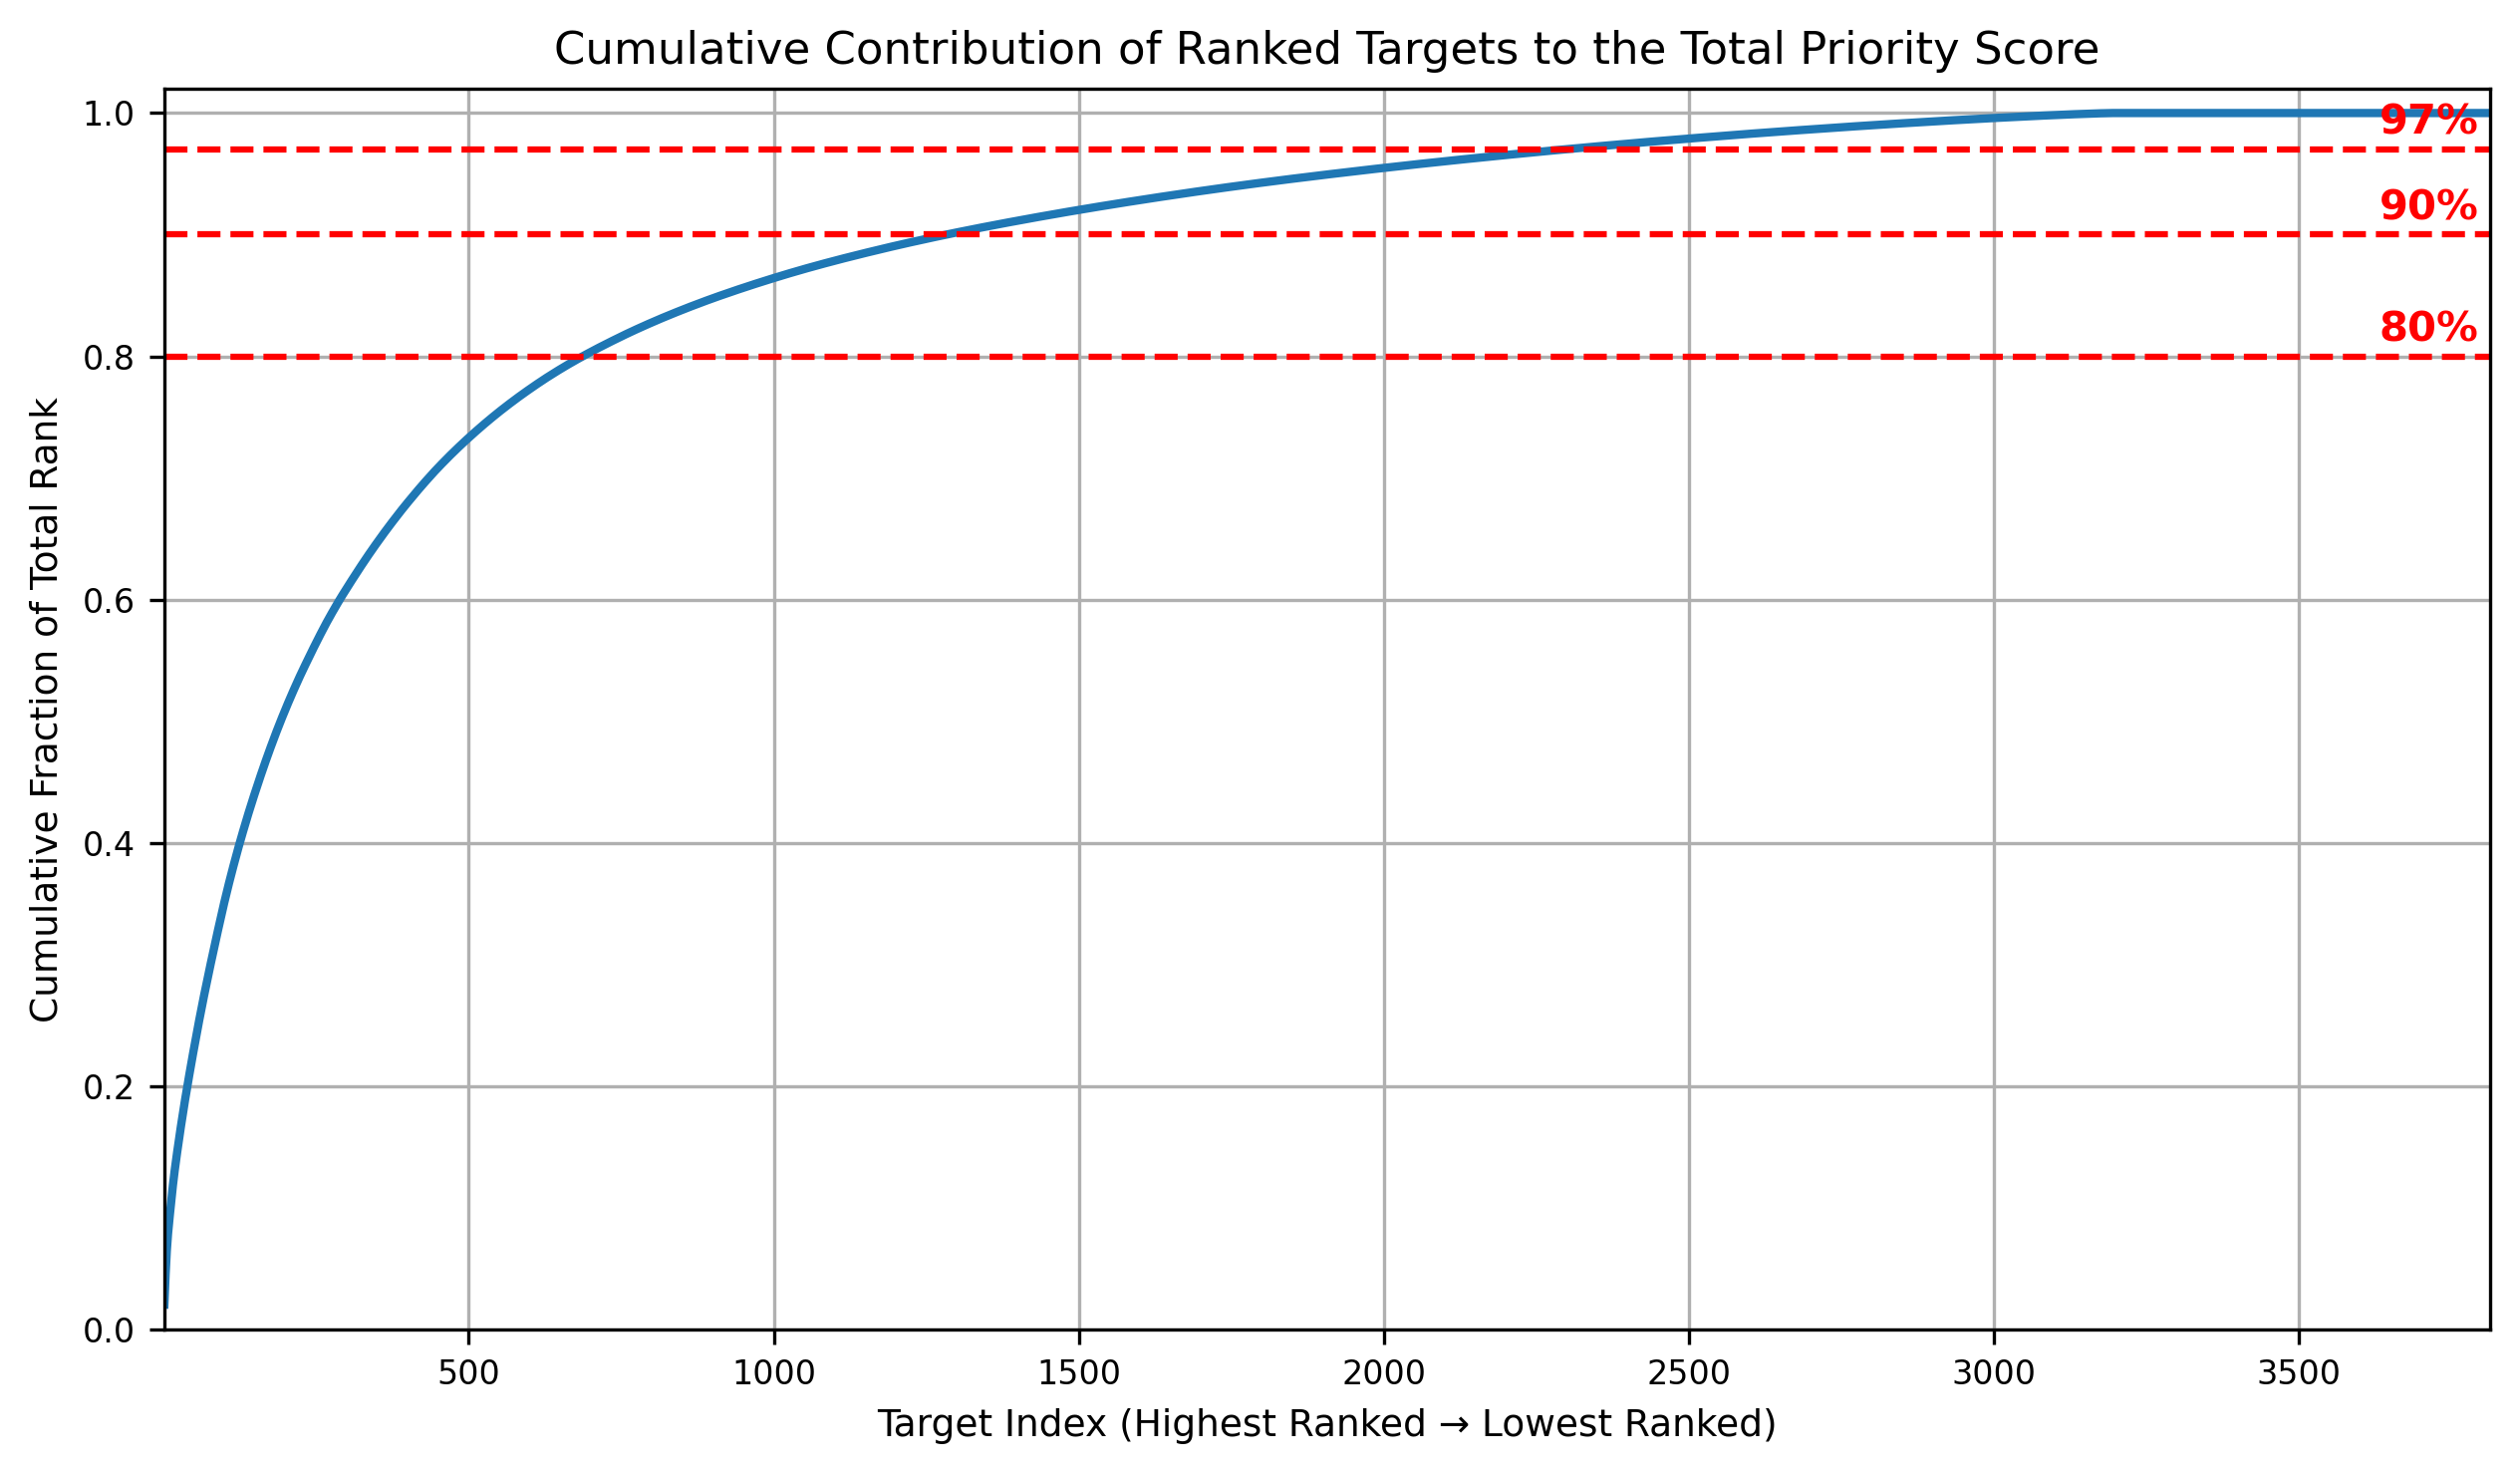

In [4]:
rank = ranked["Rank"].fillna(0).to_numpy()

cum_rank = np.cumsum(rank)
cum_rank /= cum_rank[-1]

x = np.arange(1, len(rank) + 1)

fig, ax = plt.subplots(figsize=(8.5, 5))

ax.plot(x, cum_rank, lw=2, color="tab:blue")

levels = [0.80, 0.90, 0.97]
for y in levels:
    ax.axhline(y, color="red", linestyle="--", linewidth=1.5)
    ax.text(
        len(rank) * 0.995,
        y + 0.005,
        f"{int(y*100)}%",
        color="red",
        ha="right",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_xlabel("Target Index (Highest Ranked → Lowest Ranked)")
ax.set_ylabel("Cumulative Fraction of Total Rank")
ax.set_title(
    "Cumulative Contribution of Ranked Targets to the Total Priority Score"
)

ax.set_xlim(1, len(rank))
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

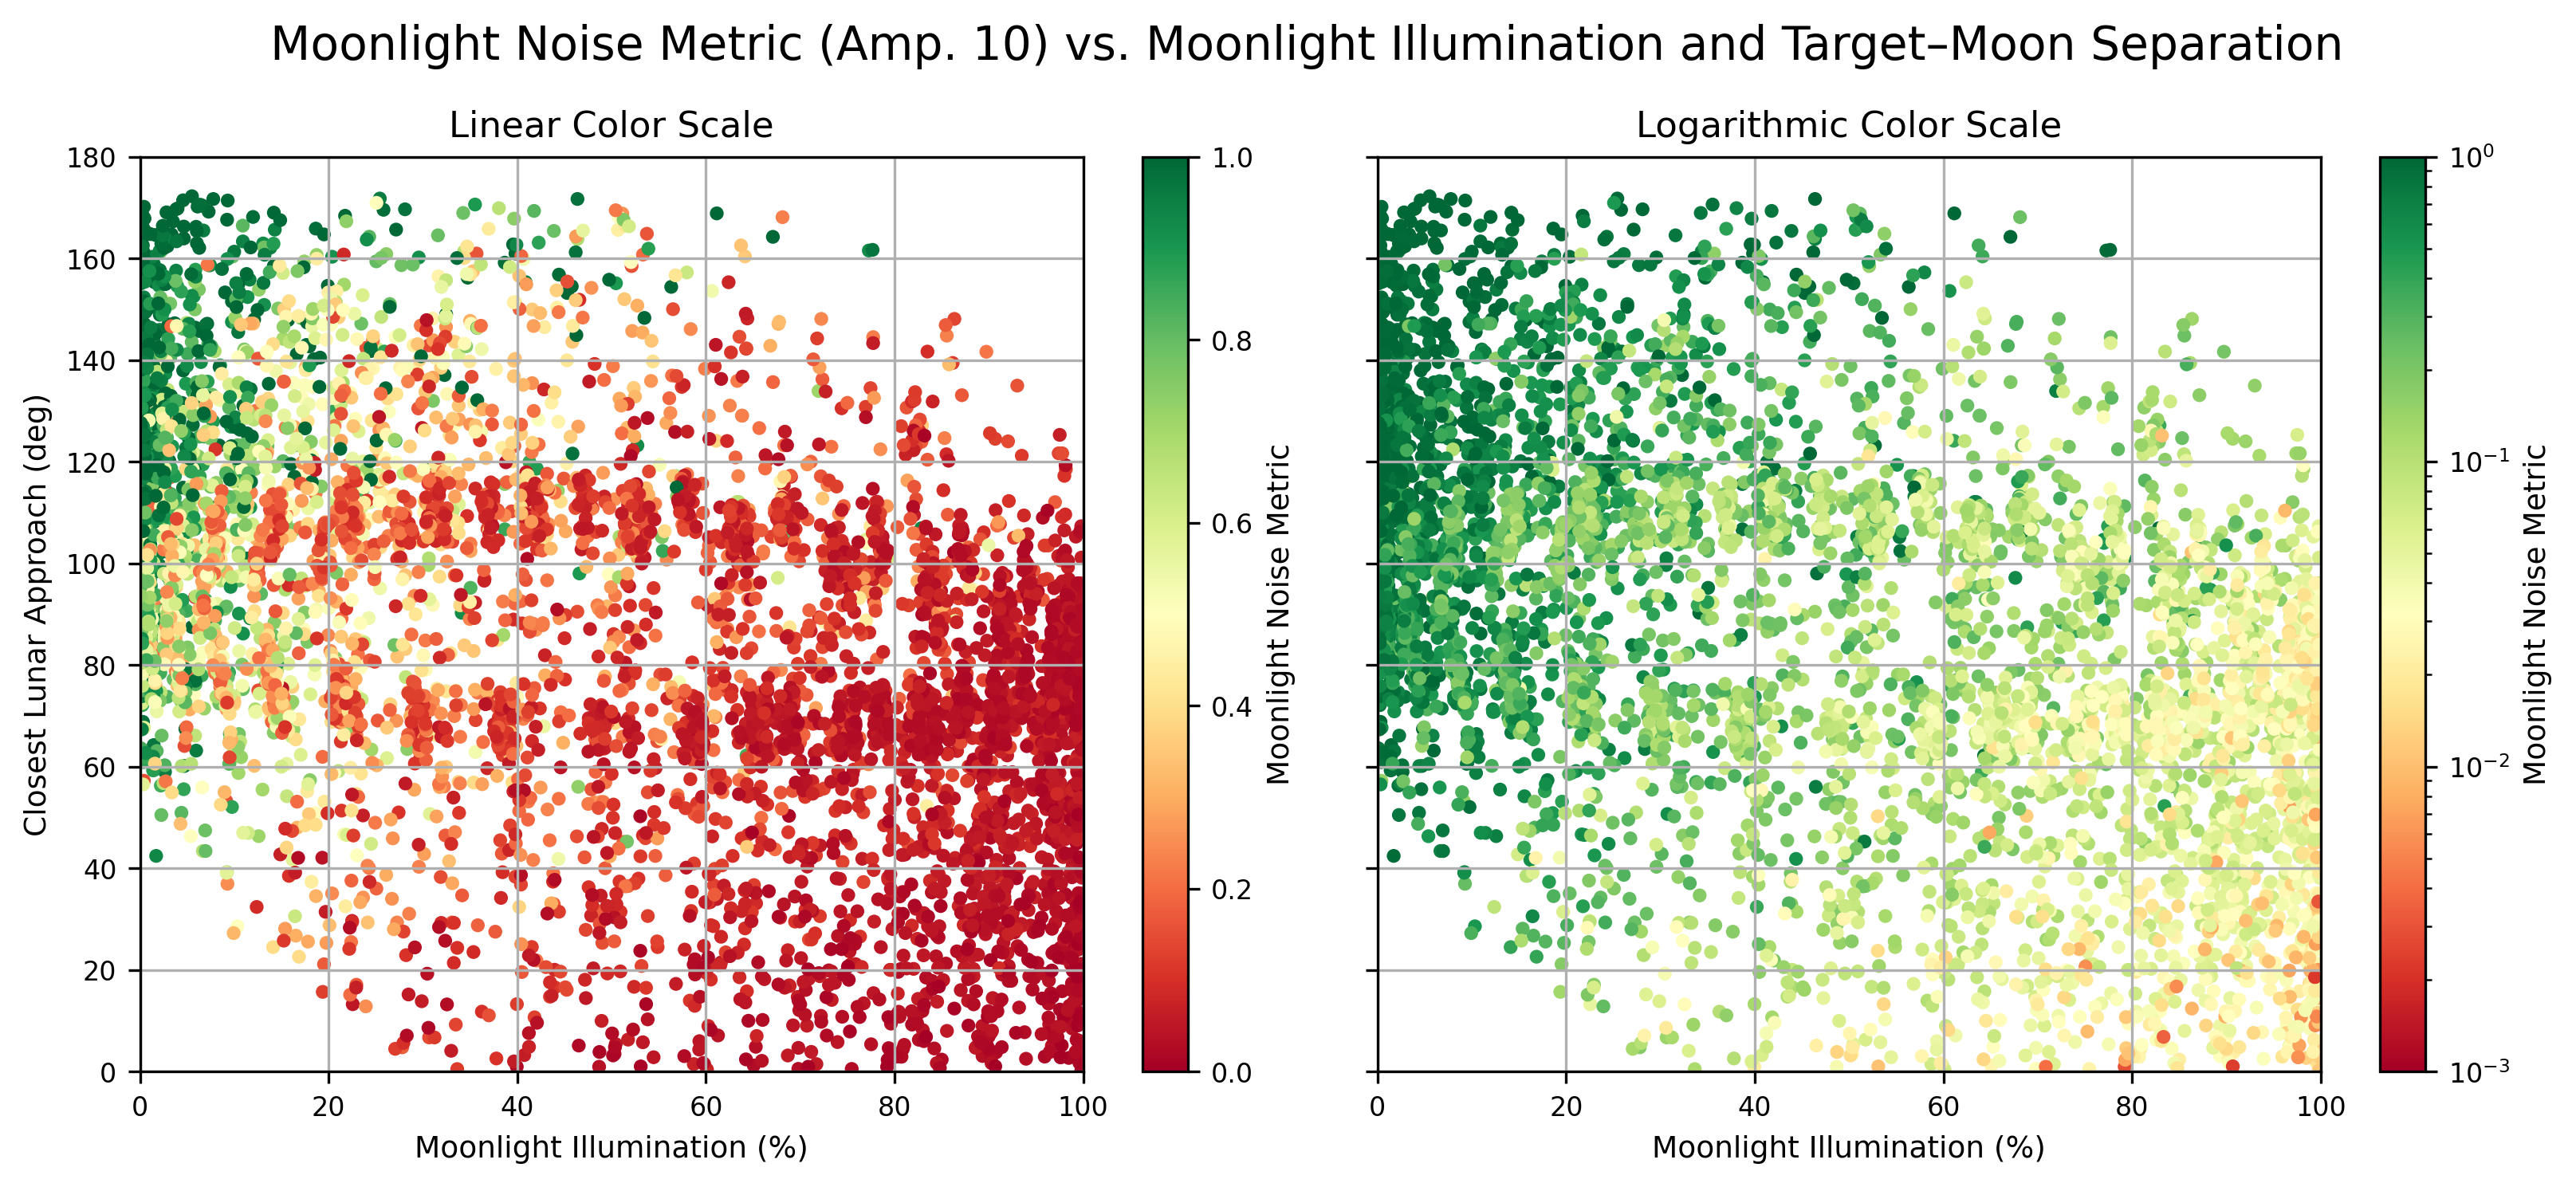

In [5]:
from matplotlib.colors import LogNorm

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

# -----------------------
# Linear color scale
# -----------------------
sc1 = ax1.scatter(
    events["Lunar_Illumination"],
    events["Closest_Lunar_Approach"],
    c=events["Moon_Noise_Metric"],
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    s=10,
)

cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label("Moonlight Noise Metric")

ax1.set_title("Linear Color Scale")
ax1.set_xlabel("Moonlight Illumination (%)")
ax1.set_ylabel("Closest Lunar Approach (deg)")
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 180)

# -----------------------
# Log color scale
# -----------------------
sc2 = ax2.scatter(
    events["Lunar_Illumination"],
    events["Closest_Lunar_Approach"],
    c=events["Moon_Noise_Metric"],
    cmap="RdYlGn",
    norm=LogNorm(vmin=1e-3, vmax=1),
    s=10,
)

cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label("Moonlight Noise Metric")

ax2.set_title("Logarithmic Color Scale")
ax2.set_xlabel("Moonlight Illumination (%)")
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 180)

fig.suptitle(
    "Moonlight Noise Metric (Amp. 10) vs. Moonlight Illumination and Target–Moon Separation",
    fontsize=14,
)

plt.tight_layout()
plt.show()

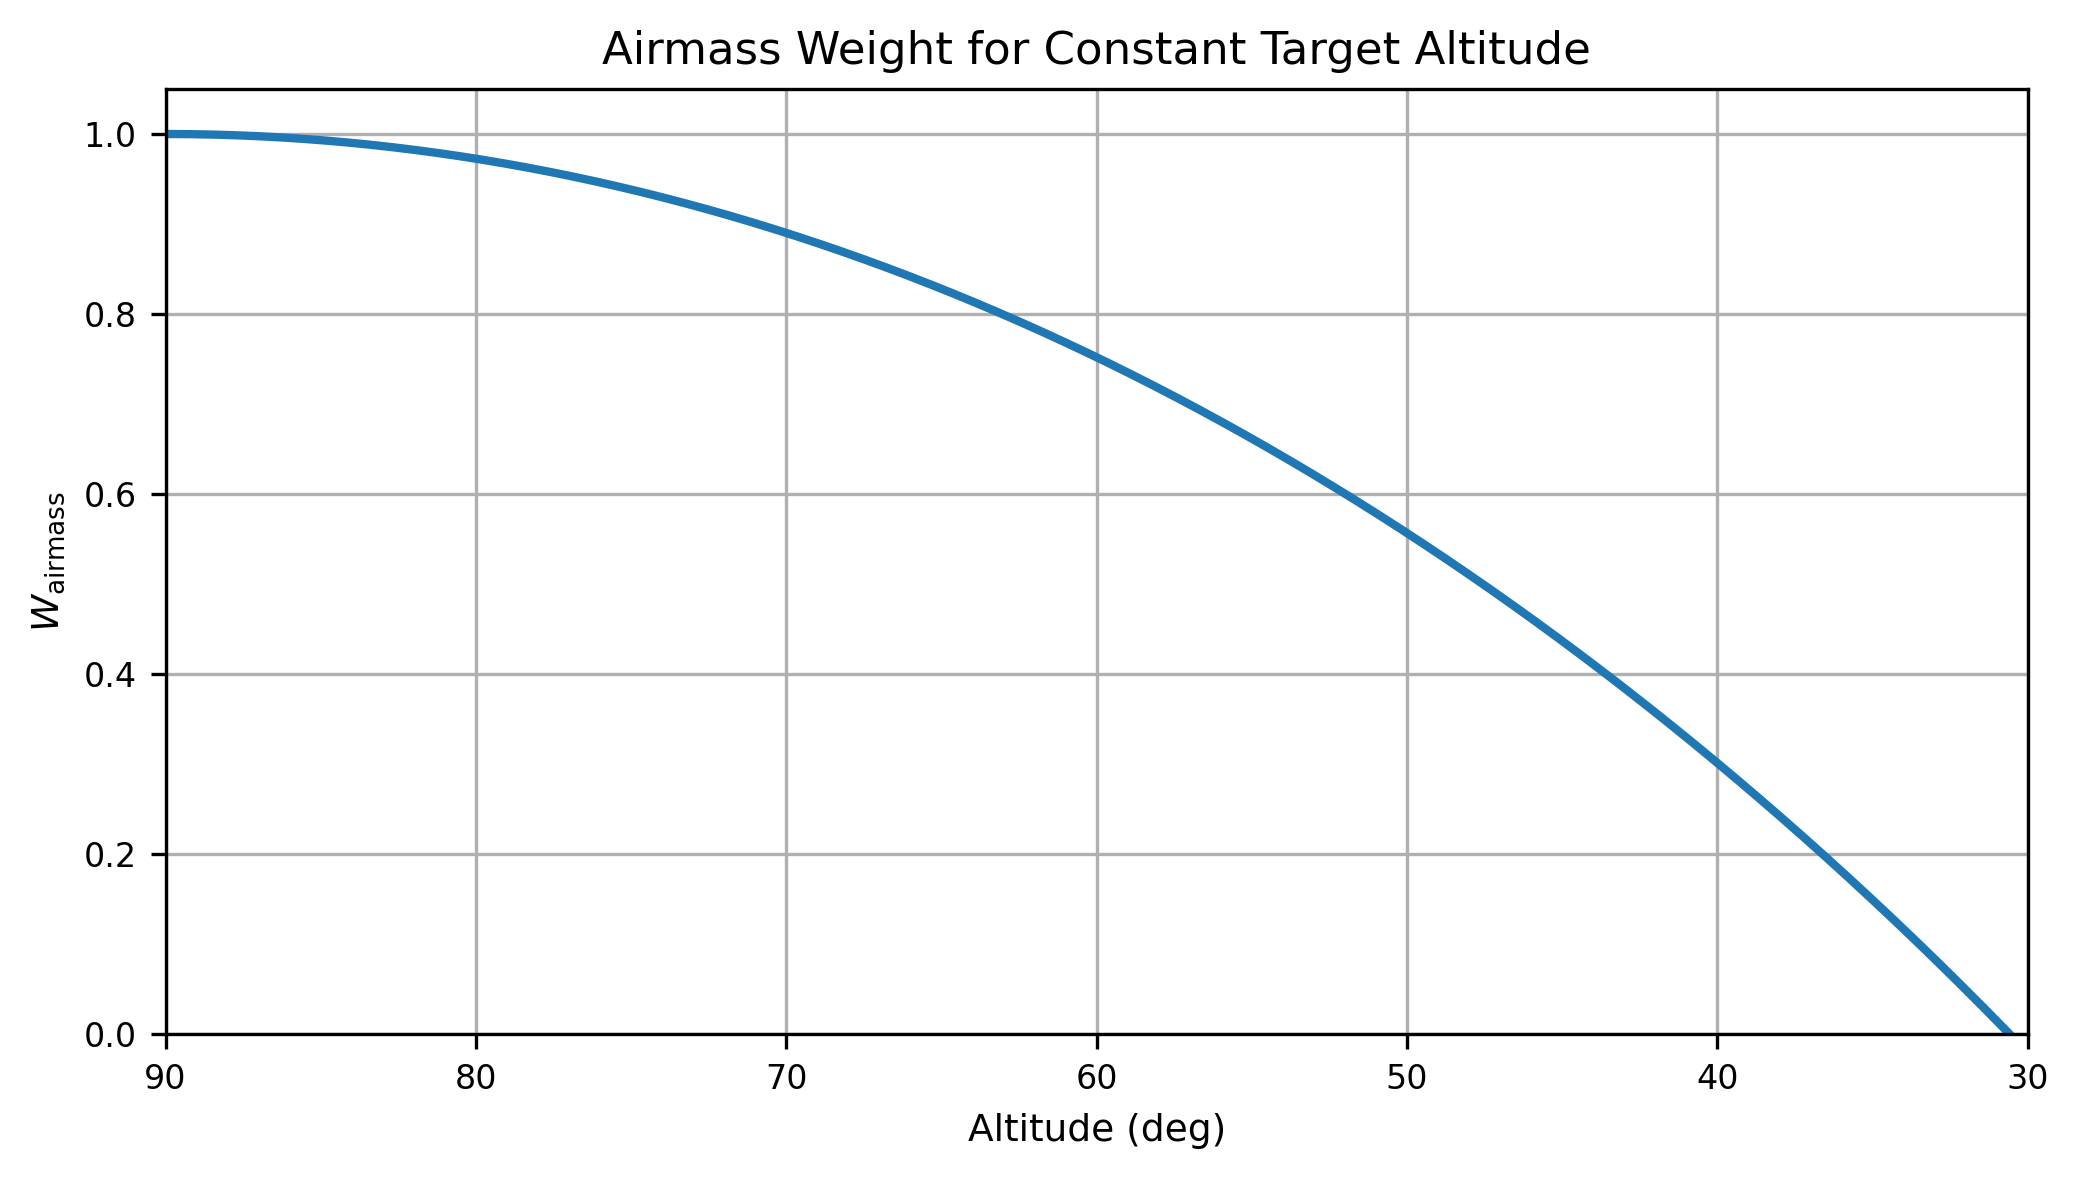

In [6]:
alt = np.linspace(30, 90, 500)

W_airmass = 3 * (np.sin(np.deg2rad(alt))**(3/5) - 2/3)

plt.figure(figsize=(7, 4))

plt.plot(alt, W_airmass, lw=2)

plt.xlabel("Altitude (deg)")
plt.ylabel(r"$W_{\rm airmass}$")
plt.title("Airmass Weight for Constant Target Altitude")

plt.xlim(90, 30)      # reverse axis
plt.ylim(0, 1.05)

plt.xticks([90, 80, 70, 60, 50, 40, 30])

plt.grid(True)
plt.tight_layout()
plt.show()